In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [11]:
final_dataset = pd.read_csv('Seoul_Mosquito_Final_Dataset.csv')
final_dataset.head()

,tm,mosquito_value_house,mosquito_value_park,STN,WS_AVG,WR_DAY,WD_MAX,WS_MAX,WS_MAX_TM,WD_INS,...,TE_15,TE_30,TE_50,날짜,수온,pH,용존산소(㎎/L),총질소(㎎/L),총인(㎎/L),총유기탄소
0,20200501,32.6,47.0,108,2.7,2328,29,5.5,1726,29,...,12.6,12.8,13.4,2020-05-01,21.298611,7.298611,6.229167,8.086181,0.116528,6.862500
1,20200502,36.6,52.7,108,2.3,1985,23,4.6,111,29,...,12.7,12.8,13.4,2020-05-02,21.418056,7.183333,5.615278,7.697153,0.201667,5.084722
2,20200503,43.0,62.0,108,2.0,1705,16,3.9,1242,14,...,12.9,12.9,13.4,2020-05-03,22.005556,7.166667,5.736111,7.444375,0.200139,5.004167
3,20200504,43.2,62.3,108,2.7,2310,27,4.6,1247,27,...,13.0,12.9,13.4,2020-05-04,23.216667,7.169444,5.648611,7.402917,0.144861,5.172348
4,20200505,46.7,67.3,108,1.9,1601,25,5.3,1354,23,...,13.2,12.9,13.4,2020-05-05,20.429167,7.102778,5.350000,7.886250,0.209861,5.837500


In [90]:
final_dataset.columns

Index(['tm', 'mosquito_value_house', 'mosquito_value_park', 'STN', 'WS_AVG',
       'WR_DAY', 'WD_MAX', 'WS_MAX', 'WS_MAX_TM', 'WD_INS', 'WS_INS',
       'WS_INS_TM', 'TA_AVG', 'TA_MAX', 'TA_MAX_TM', 'TA_MIN', 'TA_MIN_TM',
       'TD_AVG', 'TS_AVG', 'TG_MIN', 'HM_AVG', 'HM_MIN', 'HM_MIN_TM', 'PV_AVG',
       'EV_S', 'EV_L', 'FG_DUR', 'PA_AVG', 'PS_AVG', 'PS_MAX', 'PS_MAX_TM',
       'PS_MIN', 'PS_MIN_TM', 'CA_TOT', 'SS_DAY', 'SS_DUR', 'SS_CMB', 'SI_DAY',
       'SI_60M_MAX', 'SI_60M_MAX_TM', 'RN_DAY', 'RN_D99', 'RN_DUR',
       'RN_60M_MAX', 'RN_60M_MAX_TM', 'RN_10M_MAX', 'RN_10M_MAX_TM',
       'RN_POW_MAX', 'RN_POW_MAX_TM', 'SD_NEW', 'SD_NEW_TM', 'SD_MAX',
       'SD_MAX_TM', 'TE_05', 'TE_10', 'TE_15', 'TE_30', 'TE_50', '날짜', '수온',
       'pH', '용존산소(㎎/L)', '총질소(㎎/L)', '총인(㎎/L)', '총유기탄소'],
      dtype='object')

In [12]:
features = [
    'TA_AVG', 'TD_AVG', 'PV_AVG', 'TS_AVG', 'SS_DUR', 
    'TE_05', 'HM_MIN', 'CA_TOT', '수온', 'pH', '용존산소(㎎/L)'
]

# 2. 타겟 리스트
targets = ['mosquito_value_park', 'mosquito_value_house']


# 3. 데이터 분리 (예: Park 모델용 데이터)
df_park = final_dataset[features + ['mosquito_value_park']].copy()
# 데이터프레임의 마지막 컬럼 이름 확인
print("현재 설정된 타겟(y) 컬럼:", df_park.columns[-1])


df_house = final_dataset[features + ['mosquito_value_house']].copy()
# 데이터프레임의 마지막 컬럼 이름 확인
print("현재 설정된 타겟(y) 컬럼:", df_house.columns[-1])

현재 설정된 타겟(y) 컬럼: mosquito_value_park
현재 설정된 타겟(y) 컬럼: mosquito_value_house


In [13]:
def s_train_val_test(df, target_col):
    # 9:1:1 분할 (이전 코드 활용)
    n = len(df)
    train_end = int(n * 0.82)
    val_end = int(n * 0.91)
    
    train = df.iloc[:train_end]
    val = df.iloc[train_end:val_end]
    test = df.iloc[val_end:]
    
    return train, val, test

def s_train_val_test(df):
    # 9:1:1 분할 (이전 코드 활용)
    n = len(df)
    train_end = int(n * 0.82)
    val_end = int(n * 0.91)
    
    train = df.iloc[:train_end]
    val = df.iloc[train_end:val_end]
    test = df.iloc[val_end:]
    
    # 해당 타겟 전용 스케일러 생성 및 적용
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train)
    scaled_val = scaler.transform(val)
    scaled_test = scaler.transform(test)
    
    return scaled_train, scaled_val, scaled_test, scaler


s_park_train, s_park_val, s_park_test, park_scaler = s_train_val_test(df_park)
s_house_train, s_house_val, s_house_test, house_scaler = s_train_val_test(df_house)
print(f"Train: {len(s_park_train)}, Val: {len(s_park_val)}, Test: {len(s_park_test)}")
print(f"Train: {len(s_house_train)}, Val: {len(s_house_val)}, Test: {len(s_house_test)}")

Train: 896, Val: 98, Test: 99
Train: 896, Val: 98, Test: 99


In [14]:
def create_sequences(data, window_size=14):
    X, y = [], []
    for i in range(len(data) - window_size):
        # i부터 i+window_size 전까지는 입력 피처 (X)
        X.append(data[i:i+window_size, :-1]) 
        # i+window_size 시점의 마지막 컬럼은 정답 (y)
        y.append(data[i+window_size, -1])
    return np.array(X), np.array(y)

# Park 데이터셋 적용 (House도 동일하게 반복 가능)
window_size = 14
X_park_train, y_park_train = create_sequences(s_park_train, window_size)
X_park_val, y_park_val = create_sequences(s_park_val, window_size)
X_park_test, y_park_test = create_sequences(s_park_test, window_size)

print(f"학습 데이터 형태: {X_park_train.shape}") # (샘플 수, 14, 피처 수)

window_size = 14
X_house_train, y_house_train = create_sequences(s_park_train, window_size)
X_house_val, y_house_val = create_sequences(s_park_val, window_size)
X_house_test, y_house_test = create_sequences(s_park_test, window_size)

print(f"학습 데이터 형태: {X_house_train.shape}") # (샘플 수, 14, 피처 수)

학습 데이터 형태: (882, 14, 11)
학습 데이터 형태: (882, 14, 11)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# 모델 구조 정의
park_model_rnn = Sequential([
    # 1층 RNN: 시퀀스 데이터를 받아 처리
    SimpleRNN(64, return_sequences=True, input_shape=(X_park_train.shape[1], X_park_train.shape[2])),
    Dropout(0.2),
    # 2층 RNN: 좀 더 복잡한 패턴 학습
    SimpleRNN(32),
    Dropout(0.2),
    # 출력층: 최종 수치 예측
    Dense(16, activation='relu'),
    Dense(1)
])

park_model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 학습 시작
park_history = park_model_rnn.fit(
    X_park_train, y_park_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_park_val, y_park_val),
    verbose=1
)

Epoch 1/50
28/28 [==============================] - 1s 9ms/step - loss: 0.0664 - mae: 0.1970 - val_loss: 0.0299 - val_mae: 0.1414
Epoch 2/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0295 - mae: 0.1330 - val_loss: 0.0214 - val_mae: 0.1115
Epoch 3/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0238 - mae: 0.1222 - val_loss: 0.0403 - val_mae: 0.1694
Epoch 4/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0216 - mae: 0.1133 - val_loss: 0.0387 - val_mae: 0.1676
Epoch 5/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0209 - mae: 0.1110 - val_loss: 0.0421 - val_mae: 0.1706
Epoch 6/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0183 - mae: 0.1070 - val_loss: 0.0266 - val_mae: 0.1290
Epoch 7/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0179 - mae: 0.1043 - val_loss: 0.0280 - val_mae: 0.1331
Epoch 8/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0156 - mae: 0.09

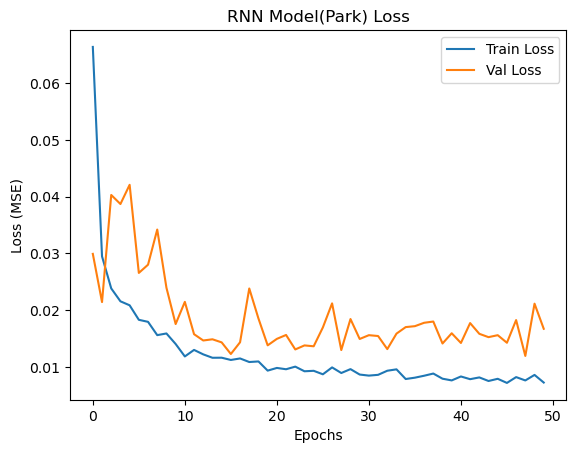

In [16]:
import matplotlib.pyplot as plt

plt.plot(park_history.history['loss'], label='Train Loss')
plt.plot(park_history.history['val_loss'], label='Val Loss')
plt.title('RNN Model(Park) Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [17]:
# 모델 구조 정의
house_model_rnn = Sequential([
    # 1층 RNN: 시퀀스 데이터를 받아 처리
    SimpleRNN(64, return_sequences=True, input_shape=(X_house_train.shape[1], X_house_train.shape[2])),
    Dropout(0.2),
    # 2층 RNN: 좀 더 복잡한 패턴 학습
    SimpleRNN(32),
    Dropout(0.2),
    # 출력층: 최종 수치 예측
    Dense(16, activation='relu'),
    Dense(1)
])

house_model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 학습 시작
house_history = house_model_rnn.fit(
    X_house_train, y_house_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_house_val, y_house_val),
    verbose=1
)

Epoch 1/50
28/28 [==============================] - 1s 8ms/step - loss: 0.2271 - mae: 0.3642 - val_loss: 0.0581 - val_mae: 0.2093
Epoch 2/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0622 - mae: 0.1965 - val_loss: 0.0201 - val_mae: 0.1168
Epoch 3/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0402 - mae: 0.1580 - val_loss: 0.0320 - val_mae: 0.1505
Epoch 4/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0333 - mae: 0.1467 - val_loss: 0.0307 - val_mae: 0.1455
Epoch 5/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0261 - mae: 0.1300 - val_loss: 0.0315 - val_mae: 0.1471
Epoch 6/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0258 - mae: 0.1270 - val_loss: 0.0222 - val_mae: 0.1164
Epoch 7/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0240 - mae: 0.1197 - val_loss: 0.0240 - val_mae: 0.1235
Epoch 8/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0208 - mae: 0.11

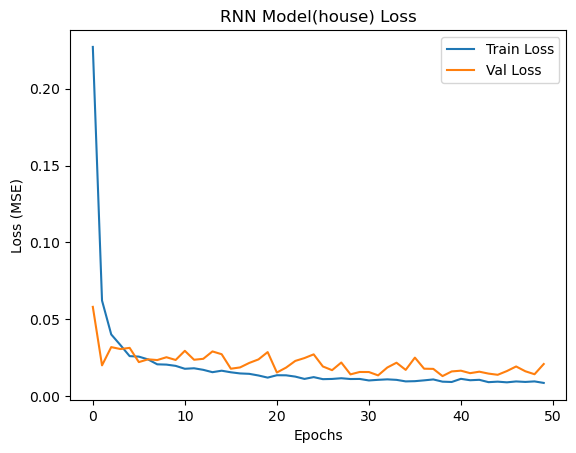

In [18]:
import matplotlib.pyplot as plt

plt.plot(house_history.history['loss'], label='Train Loss')
plt.plot(house_history.history['val_loss'], label='Val Loss')
plt.title('RNN Model(house) Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

LSTM(Park)

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 조기 종료 설정: val_loss가 7회 연속 안 좋아지면 멈춤
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=32,
                                validation_data=(X_park_val, y_park_val))

Epoch 1/50
28/28 [==============================] - 2s 21ms/step - loss: 0.0449 - mae: 0.1658 - val_loss: 0.0176 - val_mae: 0.1062
Epoch 2/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0177 - mae: 0.1037 - val_loss: 0.0211 - val_mae: 0.1117
Epoch 3/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0143 - mae: 0.0892 - val_loss: 0.0212 - val_mae: 0.1110
Epoch 4/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0136 - mae: 0.0894 - val_loss: 0.0209 - val_mae: 0.1102
Epoch 5/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0130 - mae: 0.0856 - val_loss: 0.0171 - val_mae: 0.0976
Epoch 6/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0124 - mae: 0.0842 - val_loss: 0.0141 - val_mae: 0.0899
Epoch 7/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0123 - mae: 0.0833 - val_loss: 0.0121 - val_mae: 0.0831
Epoch 8/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0118 - mae: 0.0

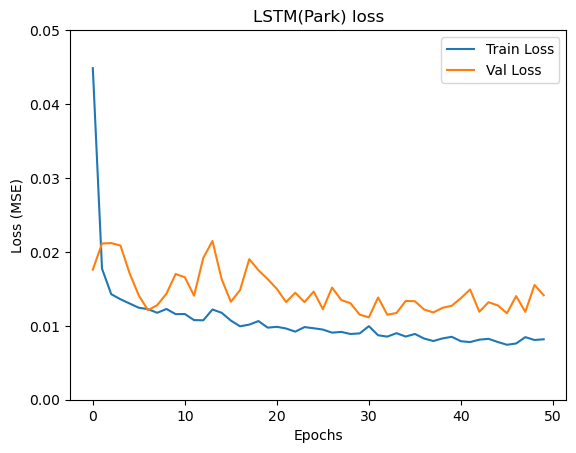

In [54]:
import matplotlib.pyplot as plt
def plot_history_fixed(history, title):
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.ylim(0, 0.05)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()

plot_history_fixed(history_p, 'LSTM(Park) loss')


학습률 조정

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 조기 종료 설정: val_loss가 7회 연속 안 좋아지면 멈춤
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=32,
                                validation_data=(X_park_val, y_park_val))

Epoch 1/50
28/28 [==============================] - 2s 21ms/step - loss: 0.0644 - mae: 0.1985 - val_loss: 0.0537 - val_mae: 0.2089
Epoch 2/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0313 - mae: 0.1428 - val_loss: 0.0318 - val_mae: 0.1533
Epoch 3/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0260 - mae: 0.1264 - val_loss: 0.0346 - val_mae: 0.1601
Epoch 4/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0223 - mae: 0.1165 - val_loss: 0.0328 - val_mae: 0.1541
Epoch 5/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0195 - mae: 0.1080 - val_loss: 0.0322 - val_mae: 0.1511
Epoch 6/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0186 - mae: 0.1052 - val_loss: 0.0326 - val_mae: 0.1513
Epoch 7/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0188 - mae: 0.1057 - val_loss: 0.0330 - val_mae: 0.1524
Epoch 8/50
28/28 [==============================] - 0s 6ms/step - loss: 0.0172 - mae: 0.1

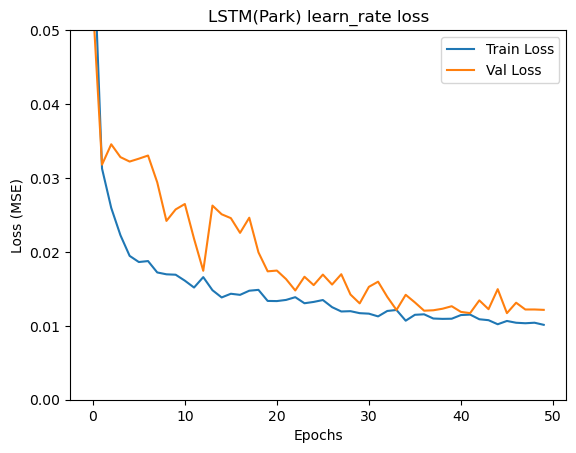

In [56]:
plot_history_fixed(history_p, 'LSTM(Park) learn_rate loss')

batch_size 조정

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 조기 종료 설정: val_loss가 7회 연속 안 좋아지면 멈춤
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=64,
                                validation_data=(X_park_val, y_park_val))

Epoch 1/50
14/14 [==============================] - 2s 44ms/step - loss: 0.1132 - mae: 0.2727 - val_loss: 0.0882 - val_mae: 0.2786
Epoch 2/50
14/14 [==============================] - 0s 14ms/step - loss: 0.0328 - mae: 0.1489 - val_loss: 0.0242 - val_mae: 0.1282
Epoch 3/50
14/14 [==============================] - 0s 14ms/step - loss: 0.0237 - mae: 0.1215 - val_loss: 0.0352 - val_mae: 0.1625
Epoch 4/50
14/14 [==============================] - 0s 14ms/step - loss: 0.0197 - mae: 0.1133 - val_loss: 0.0321 - val_mae: 0.1529
Epoch 5/50
14/14 [==============================] - 0s 14ms/step - loss: 0.0170 - mae: 0.1021 - val_loss: 0.0318 - val_mae: 0.1494
Epoch 6/50
14/14 [==============================] - 0s 14ms/step - loss: 0.0155 - mae: 0.0966 - val_loss: 0.0263 - val_mae: 0.1287
Epoch 7/50
14/14 [==============================] - 0s 14ms/step - loss: 0.0152 - mae: 0.0952 - val_loss: 0.0304 - val_mae: 0.1409
Epoch 8/50
14/14 [==============================] - 0s 14ms/step - loss: 0.0140 - m

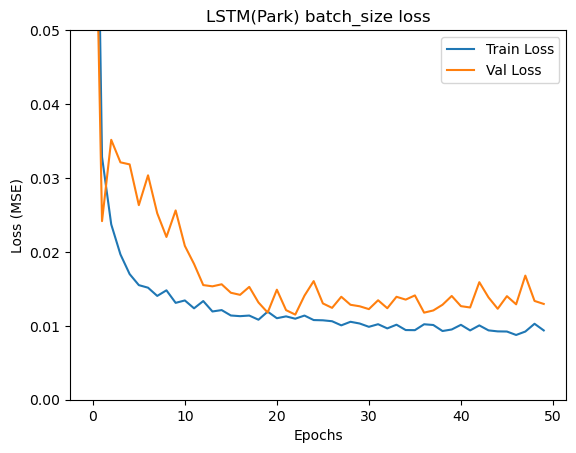

In [58]:
plot_history_fixed(history_p, 'LSTM(Park) batch_size loss')

Batch 64, learning_rate 0.0001

In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 조기 종료 설정: val_loss가 7회 연속 안 좋아지면 멈춤
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=64,
                                validation_data=(X_park_val, y_park_val))

Epoch 1/50
14/14 [==============================] - 3s 49ms/step - loss: 0.2545 - mae: 0.4499 - val_loss: 0.0403 - val_mae: 0.1634
Epoch 2/50
14/14 [==============================] - 0s 17ms/step - loss: 0.0913 - mae: 0.2475 - val_loss: 0.0311 - val_mae: 0.1453
Epoch 3/50
14/14 [==============================] - 0s 18ms/step - loss: 0.0465 - mae: 0.1746 - val_loss: 0.0654 - val_mae: 0.2316
Epoch 4/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0390 - mae: 0.1583 - val_loss: 0.0402 - val_mae: 0.1755
Epoch 5/50
14/14 [==============================] - 0s 17ms/step - loss: 0.0297 - mae: 0.1384 - val_loss: 0.0326 - val_mae: 0.1554
Epoch 6/50
14/14 [==============================] - 0s 17ms/step - loss: 0.0277 - mae: 0.1322 - val_loss: 0.0356 - val_mae: 0.1640
Epoch 7/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0241 - mae: 0.1231 - val_loss: 0.0324 - val_mae: 0.1546
Epoch 8/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0244 - m

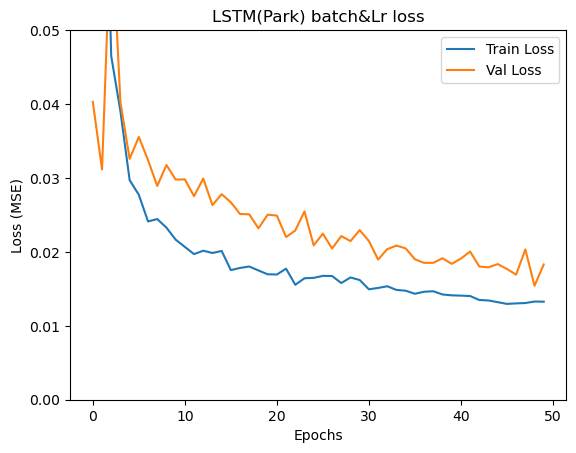

In [79]:
plot_history_fixed(history_p, 'LSTM(Park) batch&Lr loss')

Lr 0.001, BS 64

In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 조기 종료 설정: val_loss가 7회 연속 안 좋아지면 멈춤
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=64,
                                validation_data=(X_park_val, y_park_val))

Epoch 1/50
14/14 [==============================] - 2s 46ms/step - loss: 0.0560 - mae: 0.1847 - val_loss: 0.0194 - val_mae: 0.1136
Epoch 2/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0265 - mae: 0.1312 - val_loss: 0.0174 - val_mae: 0.1048
Epoch 3/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0213 - mae: 0.1146 - val_loss: 0.0214 - val_mae: 0.1139
Epoch 4/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0189 - mae: 0.1051 - val_loss: 0.0219 - val_mae: 0.1145
Epoch 5/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0174 - mae: 0.1016 - val_loss: 0.0294 - val_mae: 0.1381
Epoch 6/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0150 - mae: 0.0935 - val_loss: 0.0271 - val_mae: 0.1306
Epoch 7/50
14/14 [==============================] - 0s 14ms/step - loss: 0.0145 - mae: 0.0926 - val_loss: 0.0202 - val_mae: 0.1086
Epoch 8/50
14/14 [==============================] - 0s 14ms/step - loss: 0.0138 - m

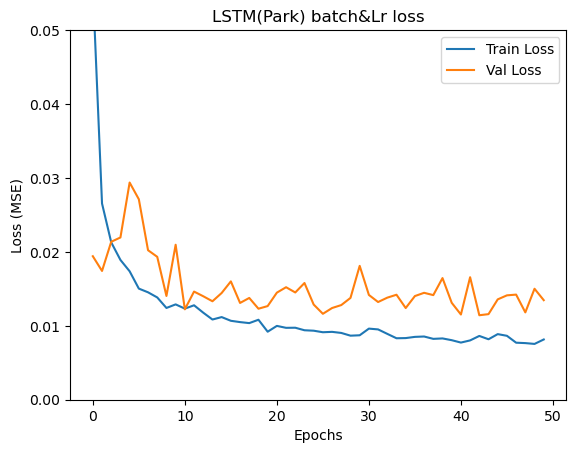

In [85]:
plot_history_fixed(history_p, 'LSTM(Park) batch&Lr loss')

ReduceLROnPlateau 적용

In [86]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# 설정: val_loss가 5회(patience) 동안 개선되지 않으면 
# 학습률을 0.2배(factor)로 줄임 (예: 0.001 -> 0.0002)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=5, 
    min_lr=0.00001, 
    verbose=1
)

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 조기 종료 설정: val_loss가 7회 연속 안 좋아지면 멈춤
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=64,
                                validation_data=(X_park_val, y_park_val), callbacks=[reduce_lr])

Epoch 1/50
14/14 [==============================] - 3s 48ms/step - loss: 0.0762 - mae: 0.2152 - val_loss: 0.0262 - val_mae: 0.1346 - lr: 0.0010
Epoch 2/50
14/14 [==============================] - 0s 17ms/step - loss: 0.0273 - mae: 0.1304 - val_loss: 0.0579 - val_mae: 0.2188 - lr: 0.0010
Epoch 3/50
14/14 [==============================] - 0s 17ms/step - loss: 0.0209 - mae: 0.1138 - val_loss: 0.0278 - val_mae: 0.1358 - lr: 0.0010
Epoch 4/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0178 - mae: 0.1037 - val_loss: 0.0257 - val_mae: 0.1258 - lr: 0.0010
Epoch 5/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0164 - mae: 0.1003 - val_loss: 0.0209 - val_mae: 0.1098 - lr: 0.0010
Epoch 6/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0156 - mae: 0.0959 - val_loss: 0.0218 - val_mae: 0.1133 - lr: 0.0010
Epoch 7/50
14/14 [==============================] - 0s 16ms/step - loss: 0.0140 - mae: 0.0916 - val_loss: 0.0182 - val_mae: 0.1013 - lr:

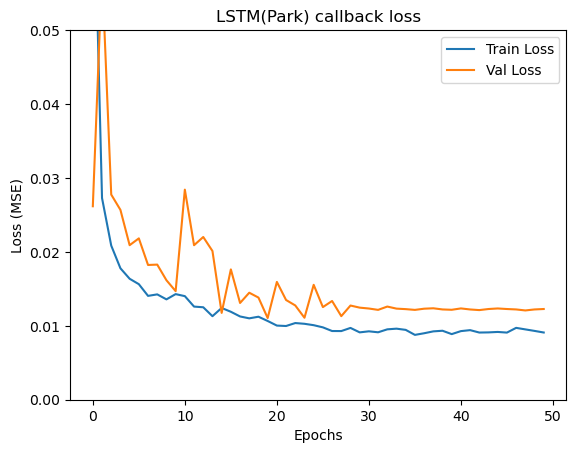

In [87]:
plot_history_fixed(history_p, 'LSTM(Park) callback loss')

예측

3/3 [==============================] - 0s 3ms/step


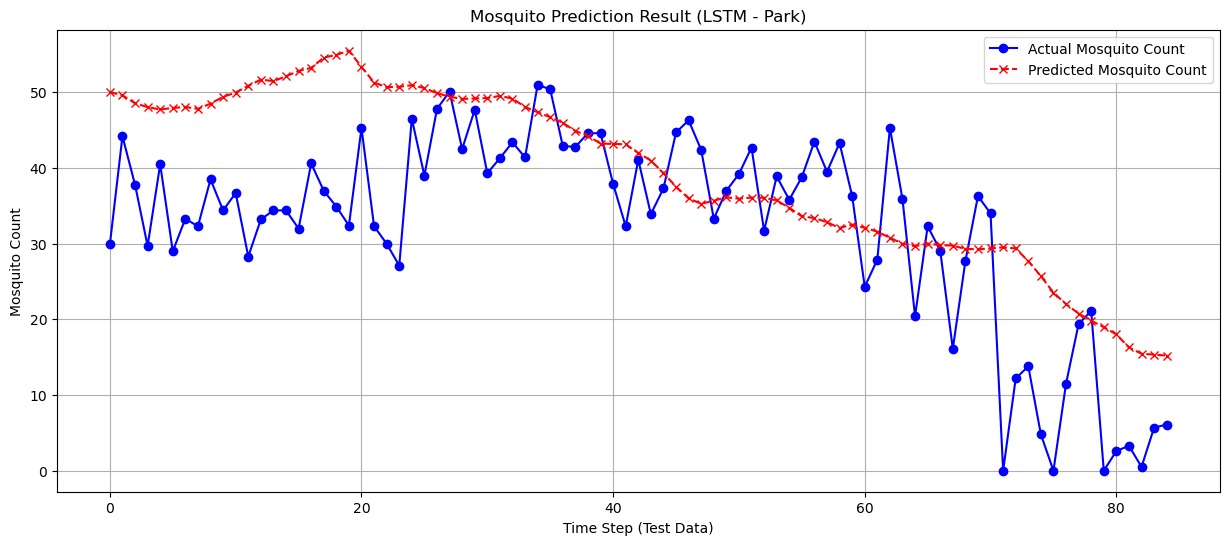

In [88]:
# 1. 테스트 데이터 예측
y_pred = model_lstm_park.predict(X_park_test)

# 2. 스케일링 역변환 (원래 마릿수로 복원)
# 예측값(y_pred)과 실제값(y_park_test) 모두 (85, 1) 형태로 확보합니다.
y_pred = y_pred.reshape(-1, 1)
y_actual = y_park_test.reshape(-1, 1)

# [수정 포인트] np.zeros의 열 개수는 'len(features)'여야 총 합이 (피처 + 타겟)이 됩니다.
# len(features)가 11개라면, 11개의 0 + 1개의 예측값 = 총 12개 컬럼 (스케일러 규격)

y_pred_rescaled = park_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_pred), len(features))), y_pred], axis=1)
)[:, -1]

y_actual_rescaled = park_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_actual), len(features))), y_actual], axis=1)
)[:, -1]

# 3. 결과 시각화
plt.figure(figsize=(15, 6))
plt.plot(y_actual_rescaled, label='Actual Mosquito Count', color='blue', marker='o')
plt.plot(y_pred_rescaled, label='Predicted Mosquito Count', color='red', linestyle='--', marker='x')
plt.title('Mosquito Prediction Result (LSTM - Park)')
plt.ylabel('Mosquito Count')
plt.xlabel('Time Step (Test Data)')
plt.legend()
plt.grid(True)
plt.show()

LSTM(house)

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf


# 조기 종료 설정: val_loss가 7회 연속 안 좋아지면 멈춤
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 1. Park용 LSTM 학습
model_lstm_house = build_lstm_model((X_house_train.shape[1], X_house_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_h = model_lstm_house.fit(X_house_train, y_house_train, epochs=80, batch_size=64,
                                validation_data=(X_house_val, y_house_val))

Epoch 1/80
14/14 [==============================] - 2s 38ms/step - loss: 0.2491 - mae: 0.4527 - val_loss: 0.0558 - val_mae: 0.2035
Epoch 2/80
14/14 [==============================] - 0s 8ms/step - loss: 0.1257 - mae: 0.3033 - val_loss: 0.0172 - val_mae: 0.1037
Epoch 3/80
14/14 [==============================] - 0s 8ms/step - loss: 0.0613 - mae: 0.2020 - val_loss: 0.0250 - val_mae: 0.1311
Epoch 4/80
14/14 [==============================] - 0s 8ms/step - loss: 0.0371 - mae: 0.1548 - val_loss: 0.0542 - val_mae: 0.2083
Epoch 5/80
14/14 [==============================] - 0s 8ms/step - loss: 0.0333 - mae: 0.1478 - val_loss: 0.0513 - val_mae: 0.2021
Epoch 6/80
14/14 [==============================] - 0s 8ms/step - loss: 0.0295 - mae: 0.1383 - val_loss: 0.0404 - val_mae: 0.1748
Epoch 7/80
14/14 [==============================] - 0s 8ms/step - loss: 0.0303 - mae: 0.1381 - val_loss: 0.0397 - val_mae: 0.1731
Epoch 8/80
14/14 [==============================] - 0s 8ms/step - loss: 0.0280 - mae: 0.1

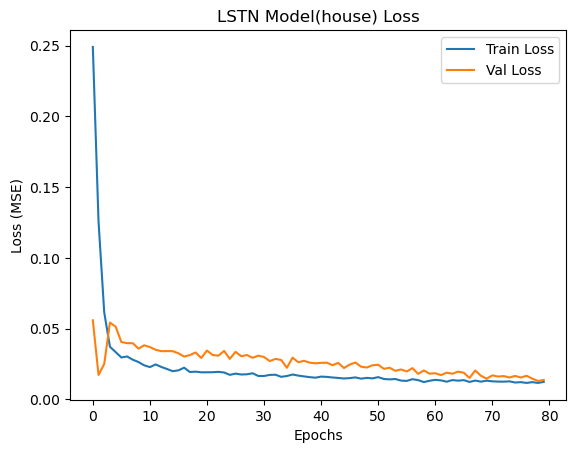

In [55]:
import matplotlib.pyplot as plt

plt.plot(history_h.history['loss'], label='Train Loss')
plt.plot(history_h.history['val_loss'], label='Val Loss')
plt.title('LSTN Model(house) Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

3/3 [==============================] - 0s 2ms/step


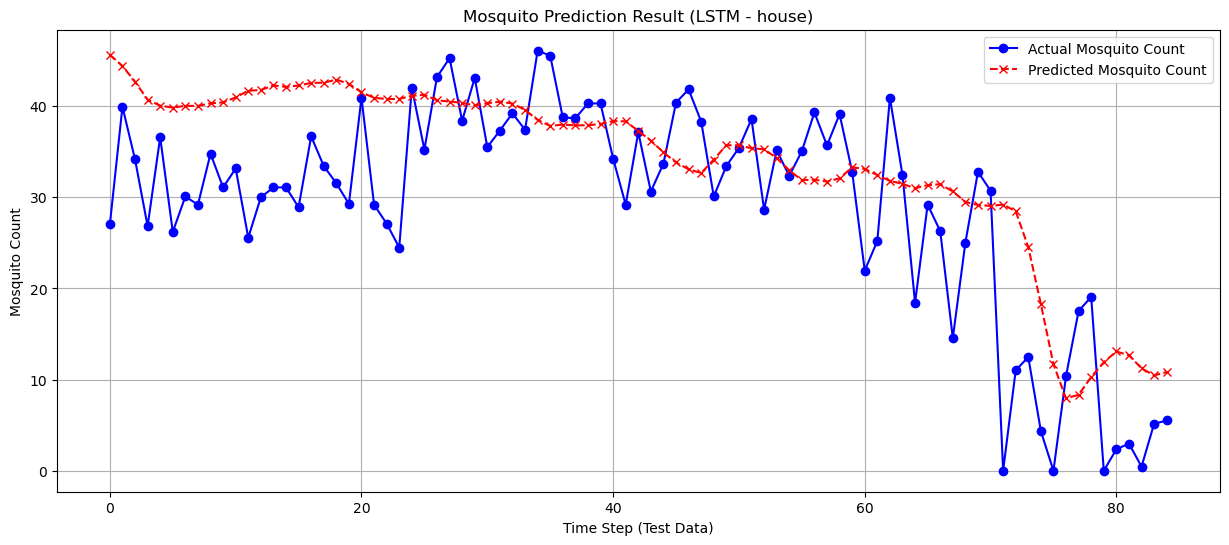

In [32]:
# 1. 테스트 데이터 예측
y_pred = model_lstm_house.predict(X_house_test)

# 2. 스케일링 역변환 (원래 마릿수로 복원)
# 예측값(y_pred)과 실제값(y_park_test) 모두 (85, 1) 형태로 확보합니다.
y_pred = y_pred.reshape(-1, 1)
y_actual = y_house_test.reshape(-1, 1)

# [수정 포인트] np.zeros의 열 개수는 'len(features)'여야 총 합이 (피처 + 타겟)이 됩니다.
# len(features)가 11개라면, 11개의 0 + 1개의 예측값 = 총 12개 컬럼 (스케일러 규격)

y_pred_rescaled = house_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_pred), len(features))), y_pred], axis=1)
)[:, -1]

y_actual_rescaled = house_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_actual), len(features))), y_actual], axis=1)
)[:, -1]

# 3. 결과 시각화
plt.figure(figsize=(15, 6))
plt.plot(y_actual_rescaled, label='Actual Mosquito Count', color='blue', marker='o')
plt.plot(y_pred_rescaled, label='Predicted Mosquito Count', color='red', linestyle='--', marker='x')
plt.title('Mosquito Prediction Result (LSTM - house)')
plt.ylabel('Mosquito Count')
plt.xlabel('Time Step (Test Data)')
plt.legend()
plt.grid(True)
plt.show()

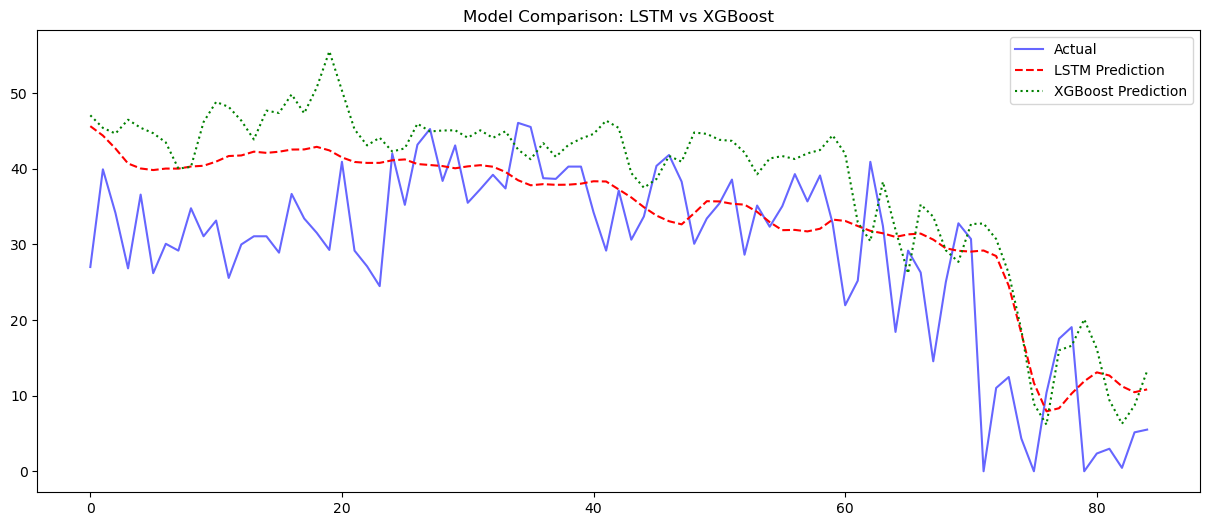

LSTM MSE: 80.7787
XGBoost MSE: 141.8963


In [33]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. 데이터 차원 변경 (3D -> 2D)
# (85, 14, 11) 형태를 (85, 14*11) 형태로 펼쳐줍니다.
X_train_flat = X_house_train.reshape(X_house_train.shape[0], -1)
X_val_flat = X_house_val.reshape(X_house_val.shape[0], -1)
X_test_flat = X_house_test.reshape(X_house_test.shape[0], -1)

# 2. XGBoost 모델 정의 및 학습
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(
    X_train_flat, y_house_train,
    eval_set=[(X_val_flat, y_house_val)],
    # early_stopping_rounds=50,
    verbose=False
)

# 3. 예측 및 역스케일링
y_pred_xgb = xgb_model.predict(X_test_flat).reshape(-1, 1)

y_pred_xgb_rescaled = house_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_pred_xgb), len(features))), y_pred_xgb], axis=1)
)[:, -1]

# 4. 결과 시각화 및 비교
plt.figure(figsize=(15, 6))
plt.plot(y_actual_rescaled, label='Actual', color='blue', alpha=0.6)
plt.plot(y_pred_rescaled, label='LSTM Prediction', color='red', linestyle='--')
plt.plot(y_pred_xgb_rescaled, label='XGBoost Prediction', color='green', linestyle=':')
plt.title('Model Comparison: LSTM vs XGBoost')
plt.legend()
plt.show()

# 5. 오차 수치 출력
print(f"LSTM MSE: {mean_squared_error(y_actual_rescaled, y_pred_rescaled):.4f}")
print(f"XGBoost MSE: {mean_squared_error(y_actual_rescaled, y_pred_xgb_rescaled):.4f}")